Numba imported


/home/skelly/school/spices/pytorch_implementation/double_gmm.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/home/skelly/school/spices/pytorch_implementation/double_gmm.py:167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


Cluster 0 Center: x=4100.04, y=4102.22
Cluster 1 Center: x=4101.35, y=4098.89
Cluster 0 Spread (Scaled Units): x_std=0.93, y_std=2.37, theta=335.91
Cluster 1 Spread (Scaled Units): x_std=2.97, y_std=3.22, theta=75.63
Background table should be larger than sources table.
Cluster 0 Center: x=4102.53, y=4112.04
Cluster 1 Center: x=4096.08, y=4096.05
Cluster 2 Center: x=4102.96, y=4107.74
Cluster 3 Center: x=4102.95, y=4093.10
Cluster 0 Spread (Scaled Units): x_std=0.47, y_std=0.73, theta=83.24
Cluster 1 Spread (Scaled Units): x_std=0.48, y_std=1.02, theta=95.77
Cluster 2 Spread (Scaled Units): x_std=0.98, y_std=1.21, theta=23.38
Cluster 3 Spread (Scaled Units): x_std=0.39, y_std=0.84, theta=90.98


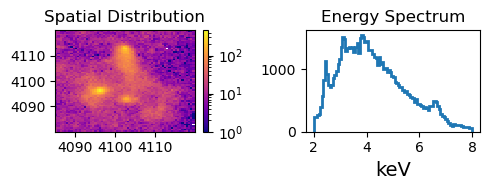

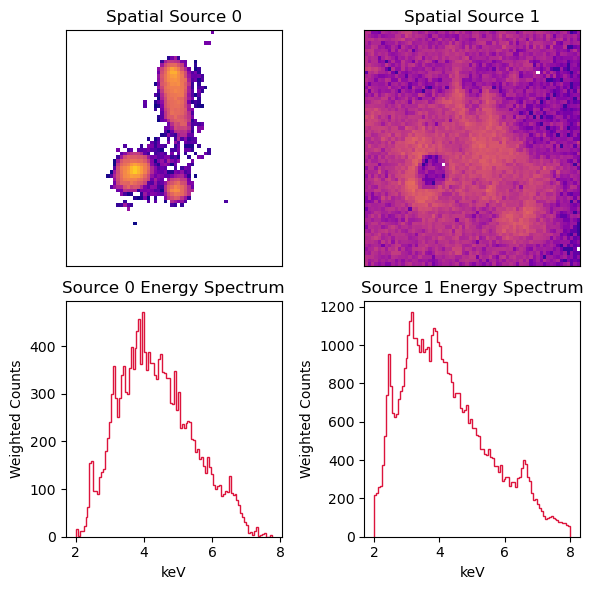

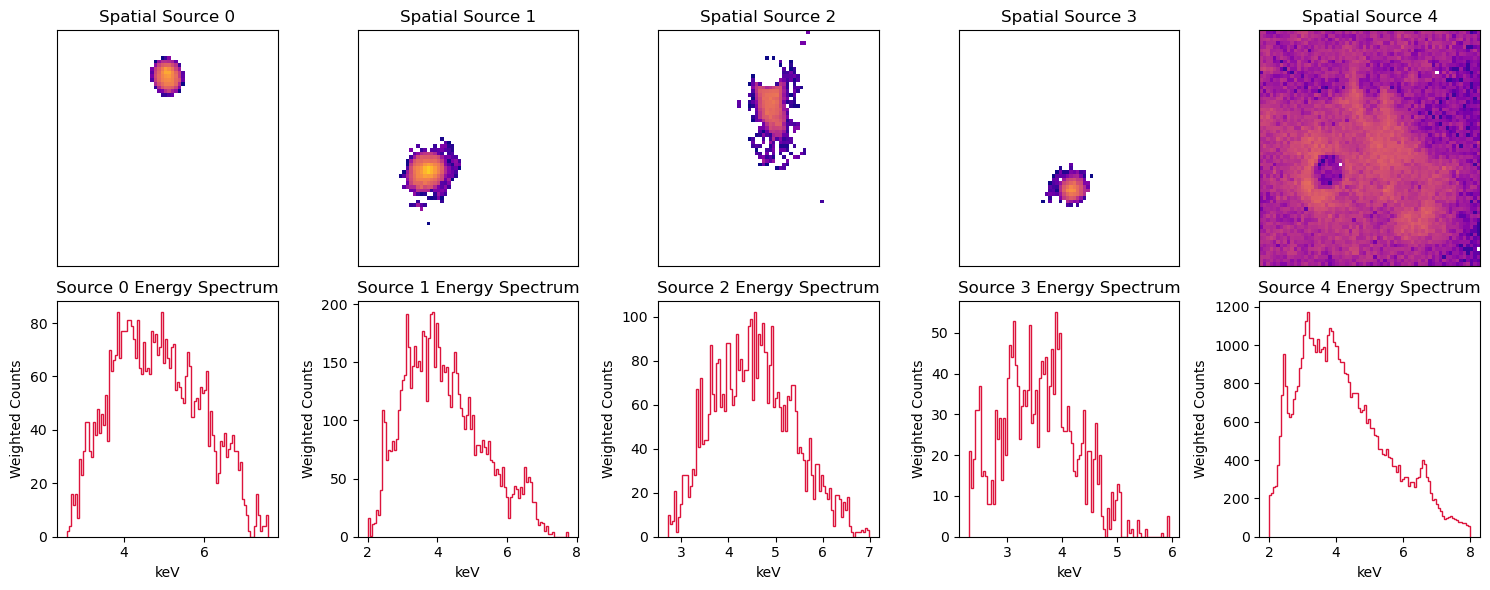

In [1]:
from double_gmm import *

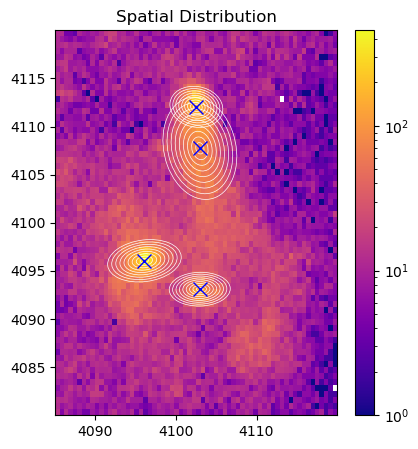

In [4]:
from matplotlib.patches import Ellipse
fig = plt.figure(figsize=(10, 5)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

for choice in range(4):
    src = split_sources[choice]
    src_center = centers[choice]
    src_std_dev = std_dev[choice]

    ax1.plot(src_center[0], src_center[1], 'bx', markersize=10, label='Center')
    for i in range(10):
        ellipse = Ellipse(xy=src_center, width=src_std_dev[0] * i, height=src_std_dev[1] * i,
                                angle = src_std_dev[2], edgecolor='w', fc='None', lw=0.5)
        ax1.add_patch(ellipse)


In [5]:
def generate_elliptical_profile(df, center, widths, angle_deg, num_bins=10):
    # 1. Setup coordinates relative to center
    dx = df['x'] - center[0]
    dy = df['y'] - center[1]
    
    # 2. Rotate coordinates to align with ellipse axes
    theta = np.radians(-angle_deg)
    x_rot = dx * np.cos(theta) - dy * np.sin(theta)
    y_rot = dx * np.sin(theta) + dy * np.cos(theta)
    
    # 3. Calculate "Elliptical Radius" 
    # This radius = 1.0 at the boundary of the ellipse defined by 'widths'
    # width/2 and height/2 represent the semi-axes (1-sigma)
    r_ell = np.sqrt((x_rot / (widths[0]))**2 + (y_rot / (widths[1]))**2)
    
    # 4. Binning
    # We'll use the 'i' from your loop as the bin index
    df['ell_bin'] = np.digitize(r_ell, bins=np.arange(num_bins + 1))
    
    # 5. Aggregate Energy
    df['weighted_energy'] = df['energy'] * df['weight']
    profile = df.groupby('ell_bin')['weighted_energy'].sum().reset_index()
    
    return profile

In [142]:
def generate_normalized_profile(df, center, widths, angle_deg, num_bins=10, prec=5.0):
    # --- 1. Calculate the Elliptical Radius ---
    dx = df['x'] - center[0]
    dy = df['y'] - center[1]
    theta = np.radians(-angle_deg)
    x_rot = dx * np.cos(theta) - dy * np.sin(theta)
    y_rot = dx * np.sin(theta) + dy * np.cos(theta)
    
    # Radii normalized to the prec-sigma widths 
    # (so when we go num_bins sigma out, we're acutally going num_bins / prec sigma out)
    r_ell = np.sqrt((x_rot / widths[0])**2 + (y_rot / widths[1])**2) * prec

    # --- 2. Binning ---
    bins = np.arange(num_bins + 1)
    df['ell_bin'] = np.digitize(r_ell, bins=bins)
    
    # --- 3. Aggregate Energy ---
    df['weighted_energy'] = df['energy']
    if 'weight' in df.columns:
        df['weighted_energy'] *= df['weight']
    
    profile = df.groupby('ell_bin')['weighted_energy'].sum().reset_index()
    
    # --- 4. Calculate Area of each Elliptical Annulus ---
    # Area of ellipse i: Pi * (a * i) * (b * i) = Pi * a * b * i^2
    def get_area(sigma_level):
        return np.pi * widths[0] * widths[1] * (sigma_level**2)

    areas = []
    for b in profile['ell_bin']:
        area_outer = get_area(b)
        area_inner = get_area(b - 1)
        areas.append(area_outer - area_inner)
    
    profile['area'] = areas
    profile['energy_density'] = profile['weighted_energy'] / profile['area']
    
    return profile

/tmp/ipykernel_23635/4287771349.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ell_bin'] = np.digitize(r_ell, bins=bins)
/tmp/ipykernel_23635/4287771349.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weighted_energy'] = df['energy']
/tmp/ipykernel_23635/4287771349.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

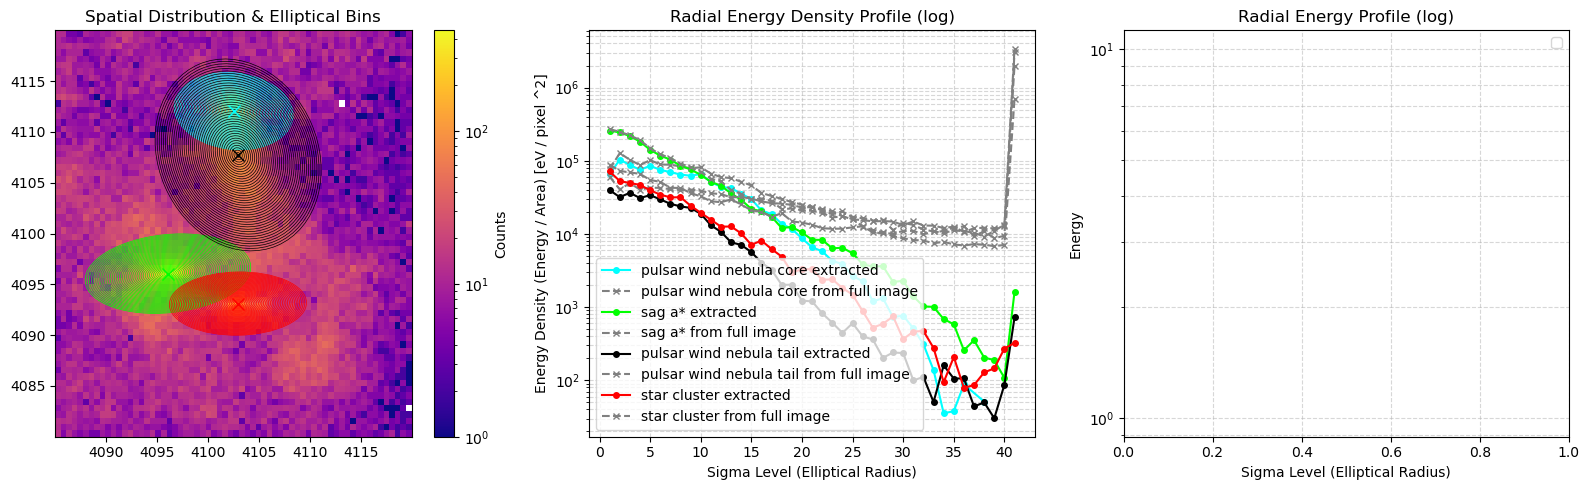

In [144]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse

# Setup the figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot the background 2D Histogram on ax1
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution & Elliptical Bins')
fig.colorbar(h2d[3], ax=ax1, label='Counts')

# Define a color palette for the 4 sources
colors = ['cyan', 'lime', 'black', 'red']
source_names = ['pulsar wind nebula core', 'sag a*', 'pulsar wind nebula tail', 'star cluster']

for choice in range(4):
    src = split_sources[choice]
    src_center = centers[choice]
    src_std_dev = std_dev[choice] # [std_x, std_y, angle]
    color = colors[choice]

    # --- Generate the Normalized Profile ---
    prec = 5.0
    num_bins = 40
    profile = generate_normalized_profile(src, src_center, src_std_dev[:2], src_std_dev[2], num_bins=num_bins, prec=prec)
    profile_base = generate_normalized_profile(subset, src_center, src_std_dev[:2], src_std_dev[2], num_bins=num_bins, prec=prec)
    
    ax1.plot(src_center[0], src_center[1], marker='x', color=color, markersize=8)
    
    for i in range(1, num_bins + 1):
        ellipse = Ellipse(xy=src_center, 
                          width=src_std_dev[0] * 2 * i / prec, 
                          height=src_std_dev[1] * 2 * i / prec,
                          angle=src_std_dev[2], 
                          edgecolor=color, fc='None', lw=0.5)
        ax1.add_patch(ellipse)

    ax2.plot(profile['ell_bin'], profile['energy_density'], 
             marker='o', markersize=4, linestyle='-', 
             color=color, label=f'{source_names[choice]} extracted')
    ax2.plot(profile_base['ell_bin'], profile_base['energy_density'], 
             marker='x', markersize=4, linestyle='--', 
             color='gray', label=f'{source_names[choice]} from full image')

# Final formatting for the Profile Plot
ax2.set_title('Radial Energy Density Profile (log)')
ax2.set_xlabel('Sigma Level (Elliptical Radius)')
ax2.set_ylabel('Energy Density (Energy / Area) [eV / pixel ^2]')
ax2.set_yscale('log')
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend()
ax3.set_title('Radial Energy Profile (log)')
ax3.set_xlabel('Sigma Level (Elliptical Radius)')
ax3.set_yscale('log')
ax3.set_ylabel('Energy')
ax3.grid(True, which="both", linestyle='--', alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.show()